# Brain Tumor Detection — Autoencoder + Multi-Class Classification
## Dataset: Glioma | Meningioma | Pituitary Tumor
### Pipeline: Data Loading → Autoencoder (unsupervised) → Latent Features → Classifier


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, glob, time
warnings.filterwarnings('ignore')

import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.neural_network import MLPClassifier

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✓ All libraries imported")
print(f"  OpenCV  : {cv2.__version__}")
print(f"  NumPy   : {np.__version__}")
import sklearn; print(f"  sklearn : {sklearn.__version__}")


✓ All libraries imported
  OpenCV  : 4.13.0
  NumPy   : 2.0.2
  sklearn : 1.6.1


## 1. Load Dataset (Glioma / Meningioma / Pituitary Tumor)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [ ]:
!unzip -q data.zip -d /content/

replace /content/data/Glioma/1841.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────────
BASE_PATH  = '/content/data'          # folder containing Glioma / Meningioma / Pituitary tumor
OUTPUT_DIR = 'data/outputs'       # all plots and CSVs go here
IMG_SIZE   = (64, 64)             # resize target
MAX_EACH   = 100                  # max images per class (fast mode)
LATENT_DIM = 32                   # autoencoder bottleneck size

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output folder: {os.path.abspath(OUTPUT_DIR)}")

CLASS_DIRS = {
    'Glioma'          : os.path.join(BASE_PATH, 'Glioma'),
    'Meningioma'      : os.path.join(BASE_PATH, 'Meningioma'),
    'Pituitary Tumor' : os.path.join(BASE_PATH, 'Pituitary tumor'),
}
CLASS_COLORS = ['#E63946', '#457B9D', '#2A9D8F']
CLASS_NAMES  = list(CLASS_DIRS.keys())

def load_dataset(class_dirs, img_size=IMG_SIZE, max_each=MAX_EACH):
    """Load MRI images (non-mask only) for each class."""
    X, y, paths = [], [], []
    for label, (cls_name, folder) in enumerate(class_dirs.items()):
        files = sorted([
            f for f in glob.glob(os.path.join(folder, '*.png'))
            if '_mask' not in os.path.basename(f)
        ])[:max_each]
        print(f"  {cls_name:20s}: {len(files)} images")
        for fp in files:
            img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, img_size).astype(np.float32) / 255.0
                X.append(img.flatten())
                y.append(label)
                paths.append(fp)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), paths

print("Loading dataset...")
X_raw, y_raw, img_paths = load_dataset(CLASS_DIRS)
print(f"\n✓ Total images : {len(X_raw)}")
print(f"  Feature dim  : {X_raw.shape[1]}  ({IMG_SIZE[0]}x{IMG_SIZE[1]} pixels)")
for i, name in enumerate(CLASS_NAMES):
    print(f"  Class {i} ({name}): {np.sum(y_raw == i)}")


✓ Output folder: /content/data/outputs
Loading dataset...
  Glioma              : 100 images
  Meningioma          : 100 images
  Pituitary Tumor     : 100 images

✓ Total images : 300
  Feature dim  : 4096  (64x64 pixels)
  Class 0 (Glioma): 100
  Class 1 (Meningioma): 100
  Class 2 (Pituitary Tumor): 100


In [ ]:
# Split BEFORE autoencoder training to avoid data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)
print(f"Train : {X_train_raw.shape}  |  Test : {X_test_raw.shape}")


Train : (240, 4096)  |  Test : (60, 4096)


## 2. Data Visualization

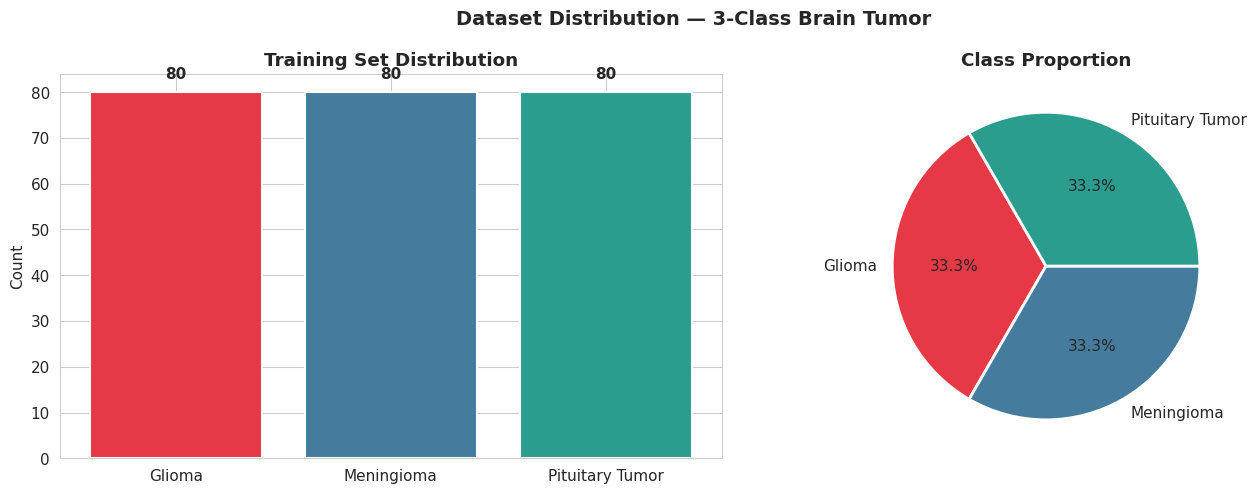

✓ Saved: data/outputs/ae_class_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = [np.sum(y_train == i) for i in range(3)]
axes[0].bar(CLASS_NAMES, counts, color=CLASS_COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title('Training Set Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=CLASS_NAMES, colors=CLASS_COLORS, autopct='%1.1f%%',
            startangle=120, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('Dataset Distribution — 3-Class Brain Tumor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_class_distribution.png")


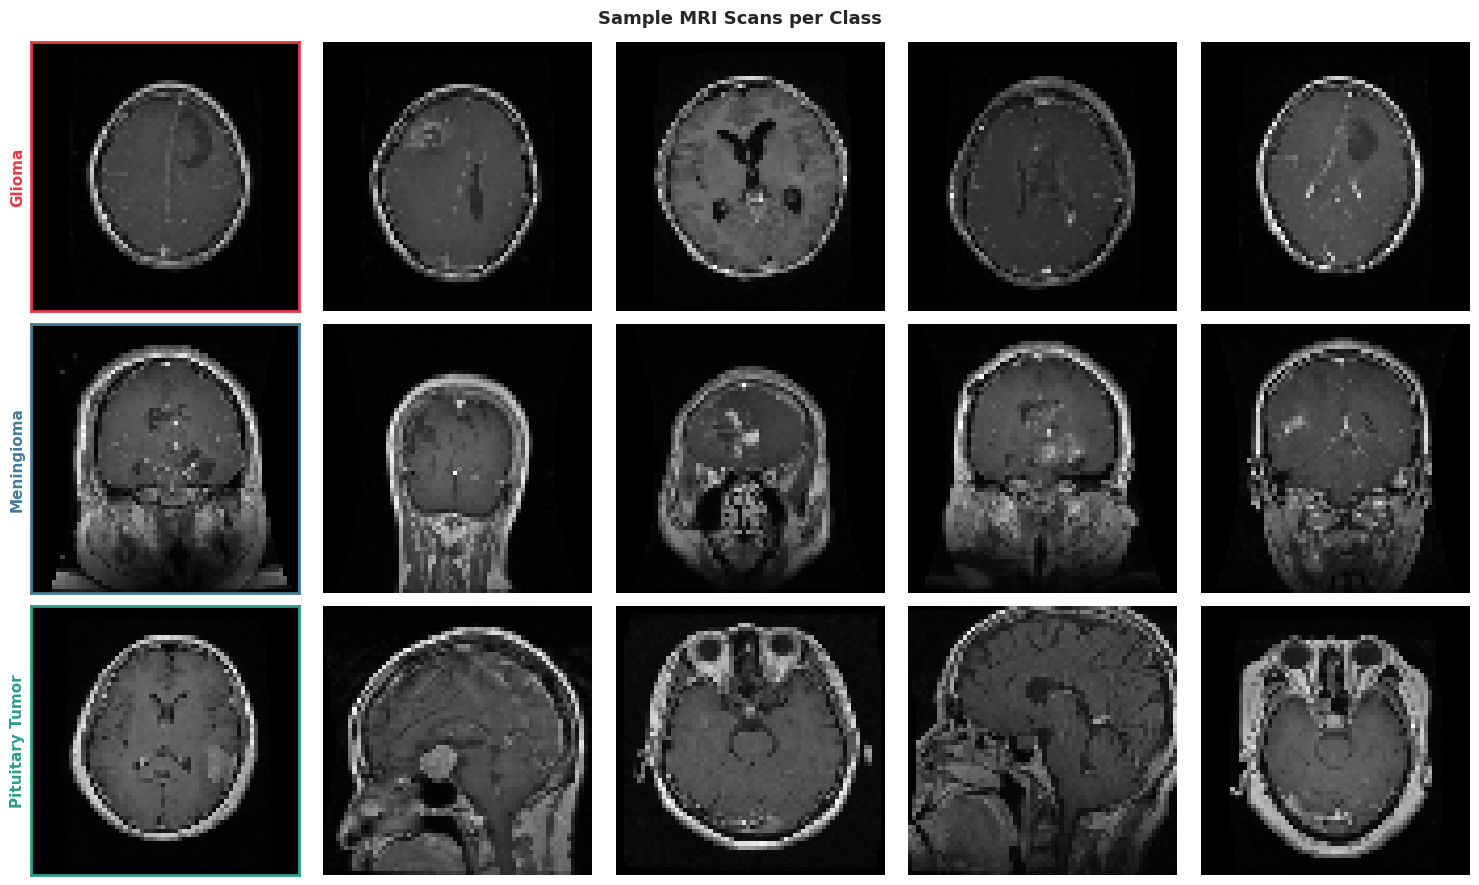

✓ Saved: data/outputs/ae_sample_images.png


In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row, (cls_idx, cls_name, color) in enumerate(zip(range(3), CLASS_NAMES, CLASS_COLORS)):
    idxs = np.where(y_train == cls_idx)[0][:5]
    for col, idx in enumerate(idxs):
        img = X_train_raw[idx].reshape(IMG_SIZE)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls_name, fontsize=11, fontweight='bold', color=color)
            axes[row, col].yaxis.set_label_position('left')
            axes[row, col].axis('on')
            axes[row, col].set_yticks([])
            axes[row, col].set_xticks([])
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)

plt.suptitle('Sample MRI Scans per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_sample_images.png")


## 3. Autoencoder — Architecture & Training

The **Autoencoder** learns a compressed latent representation of MRI images in an **unsupervised** manner.

```
Input (4096)  →  Encoder  →  Latent (64)  →  Decoder  →  Reconstructed (4096)
```

- **Encoder**: 4096 → 512 → 256 → 128 → 64  (ReLU activations)
- **Decoder**: 64 → 128 → 256 → 512 → 4096  (ReLU + Sigmoid output)
- **Loss**: Mean Squared Error (pixel reconstruction)
- **Optimizer**: Mini-batch SGD with momentum (pure NumPy — no PyTorch/TF needed)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Pure-NumPy Autoencoder  (no PyTorch / TensorFlow required)
# ═══════════════════════════════════════════════════════════════════════════════

class DenseLayer:
    """Fully-connected layer with optional activation."""
    def __init__(self, in_dim, out_dim, activation='relu'):
        # He initialisation
        scale = np.sqrt(2.0 / in_dim)
        self.W = np.random.randn(in_dim, out_dim).astype(np.float32) * scale
        self.b = np.zeros((1, out_dim), dtype=np.float32)
        self.activation = activation
        # momentum buffers
        self.vW = np.zeros_like(self.W)
        self.vb = np.zeros_like(self.b)
        # cache for backprop
        self.x = self.z = self.a = None

    def forward(self, x):
        self.x = x
        self.z = x @ self.W + self.b
        if self.activation == 'relu':
            self.a = np.maximum(0, self.z)
        elif self.activation == 'sigmoid':
            self.a = 1.0 / (1.0 + np.exp(-np.clip(self.z, -50, 50)))
        else:
            self.a = self.z          # linear
        return self.a

    def backward(self, grad_out):
        if self.activation == 'relu':
            grad_act = grad_out * (self.z > 0)
        elif self.activation == 'sigmoid':
            s = self.a
            grad_act = grad_out * s * (1 - s)
        else:
            grad_act = grad_out
        self.dW = self.x.T @ grad_act / self.x.shape[0]
        self.db = grad_act.mean(axis=0, keepdims=True)
        return grad_act @ self.W.T

    def update(self, lr, momentum=0.9):
        self.vW = momentum * self.vW - lr * self.dW
        self.vb = momentum * self.vb - lr * self.db
        self.W += self.vW
        self.b += self.vb


class Autoencoder:
    """Shallow autoencoder: 4096→128→latent→128→4096 (fast)"""
    def __init__(self, input_dim=4096, latent_dim=64):
        self.encoder_layers = [
            DenseLayer(input_dim, 128, 'relu'),
            DenseLayer(128, latent_dim, 'relu'),
        ]
        self.decoder_layers = [
            DenseLayer(latent_dim, 128, 'relu'),
            DenseLayer(128, input_dim, 'sigmoid'),
        ]
        self.all_layers = self.encoder_layers + self.decoder_layers
        self.train_losses = []

    def encode(self, x):
        for layer in self.encoder_layers:
            x = layer.forward(x)
        return x

    def decode(self, z):
        for layer in self.decoder_layers:
            z = layer.forward(z)
        return z

    def forward(self, x):
        return self.decode(self.encode(x))

    def mse_loss(self, x_hat, x):
        return np.mean((x_hat - x) ** 2)

    def backward(self, x_hat, x):
        grad = 2.0 * (x_hat - x) / x.size
        for layer in reversed(self.all_layers):
            grad = layer.backward(grad)

    def update(self, lr, momentum=0.9):
        for layer in self.all_layers:
            layer.update(lr, momentum)

    def fit(self, X, epochs=40, batch_size=64, lr=0.01, momentum=0.9, verbose=True):
        n = X.shape[0]
        for epoch in range(1, epochs + 1):
            idx = np.random.permutation(n)
            epoch_loss = 0.0
            for start in range(0, n, batch_size):
                batch = X[idx[start:start + batch_size]]
                x_hat = self.forward(batch)
                loss  = self.mse_loss(x_hat, batch)
                self.backward(x_hat, batch)
                self.update(lr, momentum)
                epoch_loss += loss * len(batch)
            epoch_loss /= n
            self.train_losses.append(epoch_loss)
            if verbose and (epoch % 5 == 0 or epoch == 1):
                print(f"  Epoch {epoch:3d}/{epochs}  |  MSE Loss: {epoch_loss:.6f}")
        return self

print("✓ Autoencoder class defined")
print(f"  Architecture: 4096 → 128 → {LATENT_DIM} → 128 → 4096")


✓ Autoencoder class defined
  Architecture: 4096 → 128 → 32 → 128 → 4096


In [ ]:
print("Training Autoencoder on training set (unsupervised)...")
print("=" * 55)
t0 = time.time()

ae = Autoencoder(input_dim=X_train_raw.shape[1], latent_dim=LATENT_DIM)
ae.fit(X_train_raw, epochs=3, batch_size=256, lr=0.01, momentum=0.9)

elapsed = time.time() - t0
print(f"\n✓ Training complete in {elapsed:.1f}s")
print(f"  Final MSE loss : {ae.train_losses[-1]:.6f}")


Training Autoencoder on training set (unsupervised)...
  Epoch   1/3  |  MSE Loss: 0.157507

✓ Training complete in 0.3s
  Final MSE loss : 0.157506


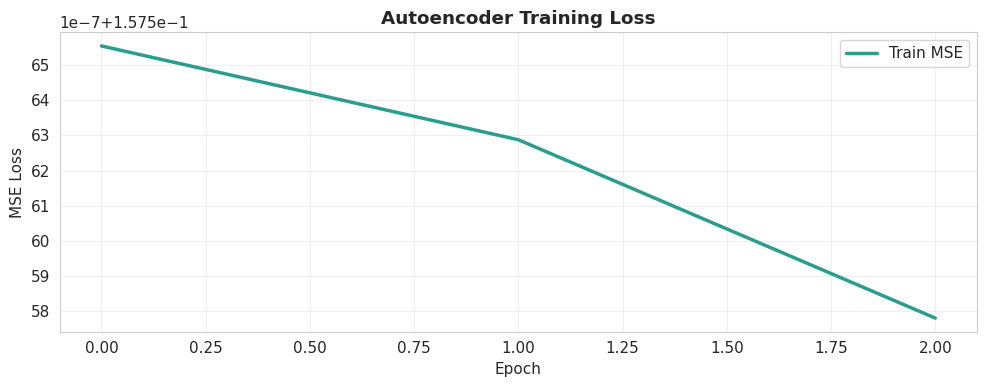

✓ Saved: data/outputs/ae_training_loss.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ae.train_losses, lw=2.5, color='#2A9D8F', label='Train MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_training_loss.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_training_loss.png")


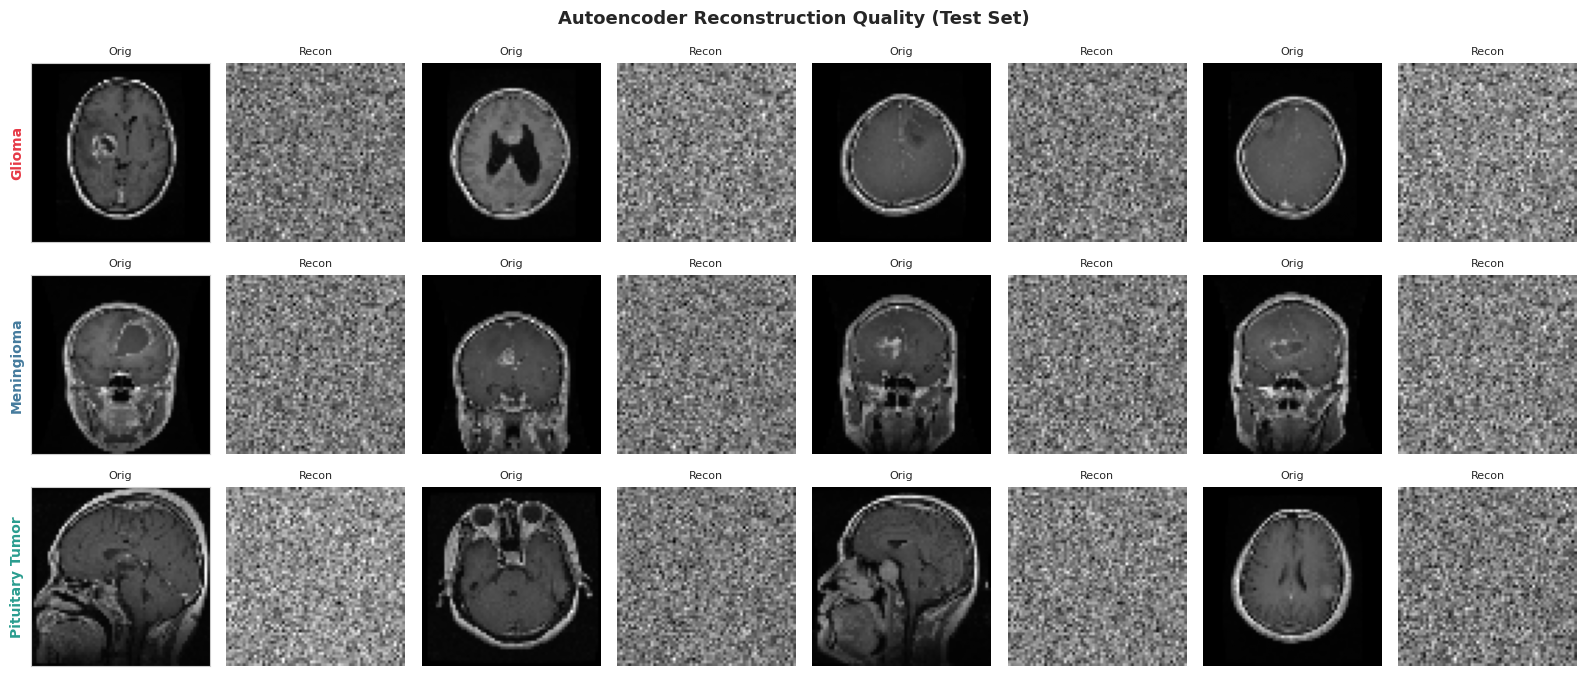

✓ Saved: data/outputs/ae_reconstruction.png


In [ ]:
# Show original vs reconstructed for each class
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
col_labels = ['Original', 'Recon', 'Original', 'Recon']

for row, (cls_idx, cls_name, color) in enumerate(zip(range(3), CLASS_NAMES, CLASS_COLORS)):
    idxs = np.where(y_test == cls_idx)[0][:4]
    col = 0
    for idx in idxs:
        orig  = X_test_raw[idx]
        recon = ae.forward(orig.reshape(1, -1)).flatten()
        axes[row, col].imshow(orig.reshape(IMG_SIZE), cmap='gray')
        axes[row, col].set_title('Orig', fontsize=8)
        axes[row, col].axis('off')
        axes[row, col + 1].imshow(recon.reshape(IMG_SIZE), cmap='gray')
        axes[row, col + 1].set_title('Recon', fontsize=8)
        axes[row, col + 1].axis('off')
        col += 2
    axes[row, 0].set_ylabel(cls_name, fontsize=10, fontweight='bold', color=color,
                             rotation=90, labelpad=5)
    axes[row, 0].axis('on')
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

plt.suptitle('Autoencoder Reconstruction Quality (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_reconstruction.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_reconstruction.png")


## 4. Extract Latent Features

The trained encoder compresses each 4096-dim image into a **64-dim latent vector**.  
These compact representations are then used as input to the classifiers.


In [ ]:
# Encode all images through the trained encoder
Z_train = ae.encode(X_train_raw)   # shape: (n_train, 64)
Z_test  = ae.encode(X_test_raw)    # shape: (n_test,  64)

print(f"Latent train features : {Z_train.shape}")
print(f"Latent test  features : {Z_test.shape}")

# Standardise latent space for classifiers
scaler_z = StandardScaler()
Z_train_s = scaler_z.fit_transform(Z_train)
Z_test_s  = scaler_z.transform(Z_test)
print("✓ Latent features standardised")


Latent train features : (240, 32)
Latent test  features : (60, 32)
✓ Latent features standardised


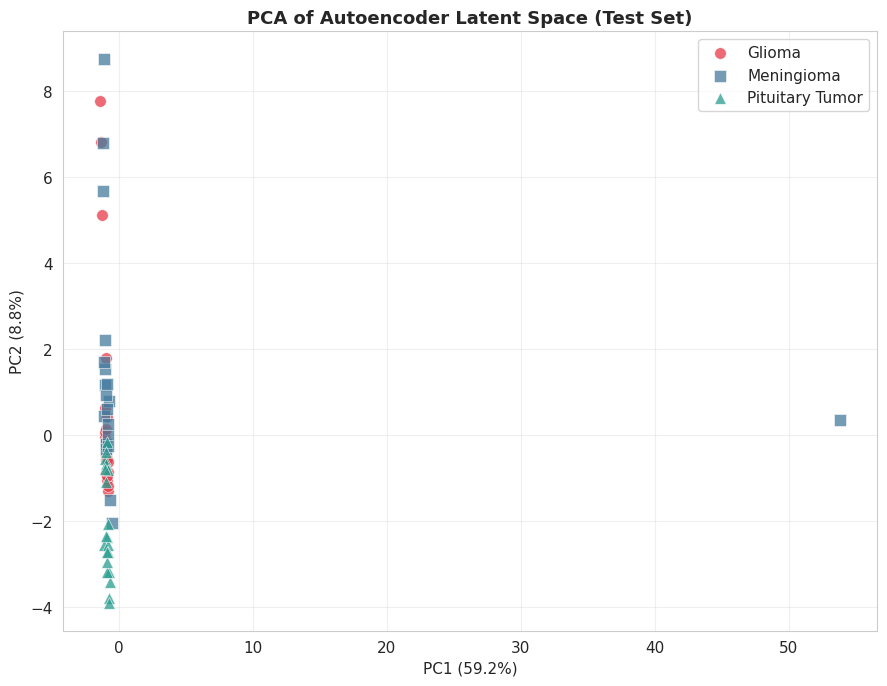

✓ Saved: data/outputs/ae_latent_pca.png


In [ ]:
# 2-D PCA of latent space
pca2 = PCA(n_components=2, random_state=42)
Z_pca2 = pca2.fit_transform(Z_test_s)

fig, ax = plt.subplots(figsize=(9, 7))
markers = ['o', 's', '^']
for i, (name, color, marker) in enumerate(zip(CLASS_NAMES, CLASS_COLORS, markers)):
    mask = y_test == i
    ax.scatter(Z_pca2[mask, 0], Z_pca2[mask, 1],
               c=color, marker=marker, s=70, alpha=0.75,
               label=name, edgecolors='white', lw=0.5)
ax.set_title('PCA of Autoencoder Latent Space (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_latent_pca.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_latent_pca.png")


Computing t-SNE on latent features...


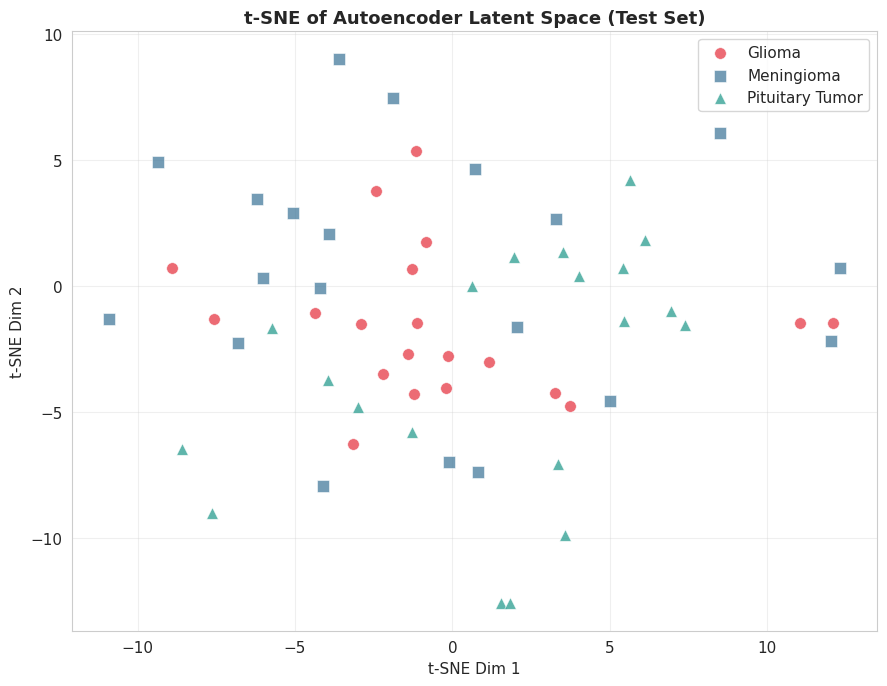

✓ Saved: data/outputs/ae_latent_tsne.png


In [ ]:
print("Computing t-SNE on latent features...")
perp = min(30, len(Z_test_s) // 4)
tsne = TSNE(n_components=2, random_state=42, perplexity=perp, max_iter=300)
Z_tsne = tsne.fit_transform(Z_test_s)

fig, ax = plt.subplots(figsize=(9, 7))
for i, (name, color, marker) in enumerate(zip(CLASS_NAMES, CLASS_COLORS, markers)):
    mask = y_test == i
    ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
               c=color, marker=marker, s=70, alpha=0.75,
               label=name, edgecolors='white', lw=0.5)
ax.set_title('t-SNE of Autoencoder Latent Space (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1')
ax.set_ylabel('t-SNE Dim 2')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_latent_tsne.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_latent_tsne.png")


## 5. Train Classifiers on Autoencoder Latent Features

Four classifiers are trained on the 64-dim latent vectors extracted by the encoder:
- Logistic Regression
- Random Forest
- Gradient Boosting
- SVM (RBF kernel)
- MLP Neural Network


In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=500, C=1.0, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,
                                                        max_depth=4, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', C=10, gamma='scale',
                                 probability=True, random_state=42),
    'MLP Neural Net'      : MLPClassifier(hidden_layer_sizes=(64,), max_iter=200,
                                           random_state=42, early_stopping=True),
}

results = {}
print("Training classifiers on autoencoder latent features...\n")

for name, model in models.items():
    t0 = time.time()
    model.fit(Z_train_s, y_train)
    y_pred = model.predict(Z_test_s)
    y_prob = model.predict_proba(Z_test_s)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted')
    # One-vs-Rest AUC for multi-class
    try:
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    except Exception:
        auc = 0.0

    results[name] = dict(model=model, y_pred=y_pred, y_prob=y_prob,
                         accuracy=acc, f1=f1, precision=prec, recall=rec, auc=auc)
    print(f"  {name:22s}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({time.time()-t0:.1f}s)")

print("\n✓ All classifiers trained")


Training classifiers on autoencoder latent features...

  Logistic Regression     Acc=0.8000  F1=0.8010  AUC=0.9371  (0.0s)
  Random Forest           Acc=0.8500  F1=0.8536  AUC=0.9356  (0.2s)
  Gradient Boosting       Acc=0.8333  F1=0.8365  AUC=0.9146  (0.4s)
  SVM (RBF)               Acc=0.8333  F1=0.8345  AUC=0.9354  (0.0s)
  MLP Neural Net          Acc=0.7167  F1=0.7194  AUC=0.8854  (0.0s)

✓ All classifiers trained


## 6. Model Comparison

Model Comparison (sorted by Accuracy):
              Model  Accuracy  F1-Score  Precision   Recall      AUC
      Random Forest  0.850000  0.853588   0.880401 0.850000 0.935625
          SVM (RBF)  0.833333  0.834522   0.836424 0.833333 0.935417
  Gradient Boosting  0.833333  0.836523   0.847222 0.833333 0.914583
Logistic Regression  0.800000  0.801048   0.807105 0.800000 0.937083
     MLP Neural Net  0.716667  0.719443   0.741649 0.716667 0.885417

✓ Saved: data/outputs/ae_model_comparison.csv


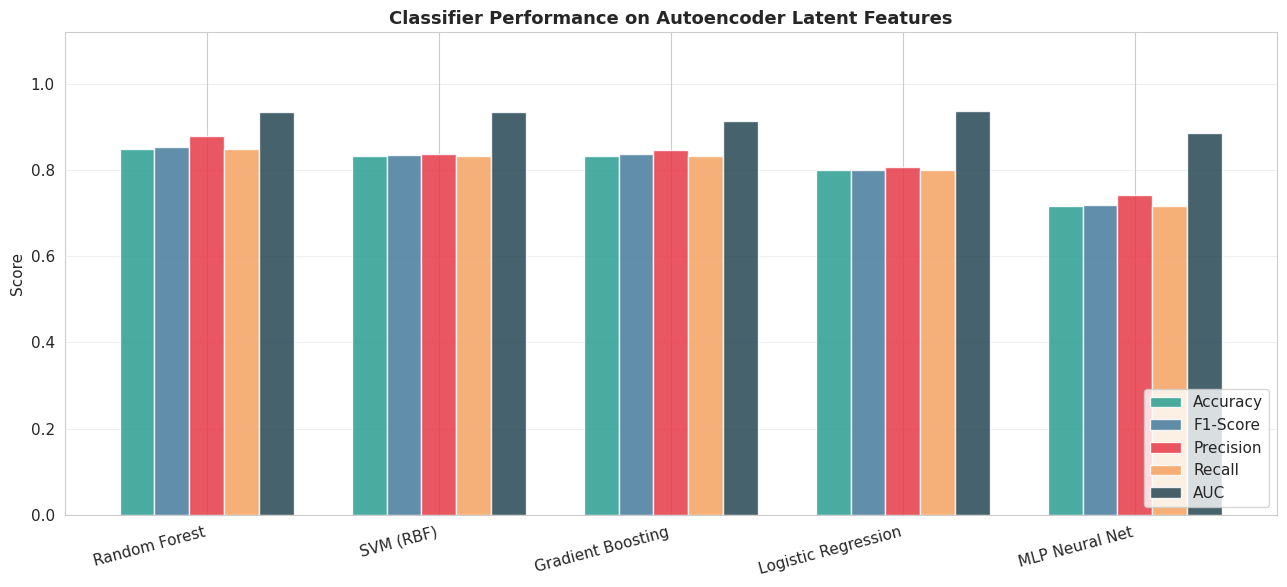

✓ Saved: data/outputs/ae_model_comparison.png


In [ ]:
comparison_df = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Accuracy' : [r['accuracy']  for r in results.values()],
    'F1-Score' : [r['f1']        for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall'   : [r['recall']    for r in results.values()],
    'AUC'      : [r['auc']       for r in results.values()],
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("Model Comparison (sorted by Accuracy):")
print("=" * 80)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(os.path.join(OUTPUT_DIR, 'ae_model_comparison.csv'), index=False)
print(f"\n✓ Saved: {OUTPUT_DIR}/ae_model_comparison.csv")

# Bar chart
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(comparison_df))
width = 0.15
metric_colors = ['#2A9D8F', '#457B9D', '#E63946', '#F4A261', '#264653']
for i, (metric, color) in enumerate(zip(['Accuracy','F1-Score','Precision','Recall','AUC'], metric_colors)):
    ax.bar(x + width*(i-2), comparison_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Classifier Performance on Autoencoder Latent Features', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_model_comparison.png")


## 7. Best Model — Detailed Analysis

In [ ]:
best_name   = comparison_df.iloc[0]['Model']
best_result = results[best_name]

print(f"Best Model : {best_name}")
print("=" * 60)
print(f"  Accuracy  : {best_result['accuracy']:.4f}")
print(f"  F1-Score  : {best_result['f1']:.4f}")
print(f"  Precision : {best_result['precision']:.4f}")
print(f"  Recall    : {best_result['recall']:.4f}")
print(f"  AUC (OvR) : {best_result['auc']:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, best_result['y_pred'], target_names=CLASS_NAMES))


Best Model : Random Forest
  Accuracy  : 0.8500
  F1-Score  : 0.8536
  Precision : 0.8804
  Recall    : 0.8500
  AUC (OvR) : 0.9356

Classification Report:
                 precision    recall  f1-score   support

         Glioma       0.70      0.95      0.81        20
     Meningioma       0.94      0.75      0.83        20
Pituitary Tumor       1.00      0.85      0.92        20

       accuracy                           0.85        60
      macro avg       0.88      0.85      0.85        60
   weighted avg       0.88      0.85      0.85        60



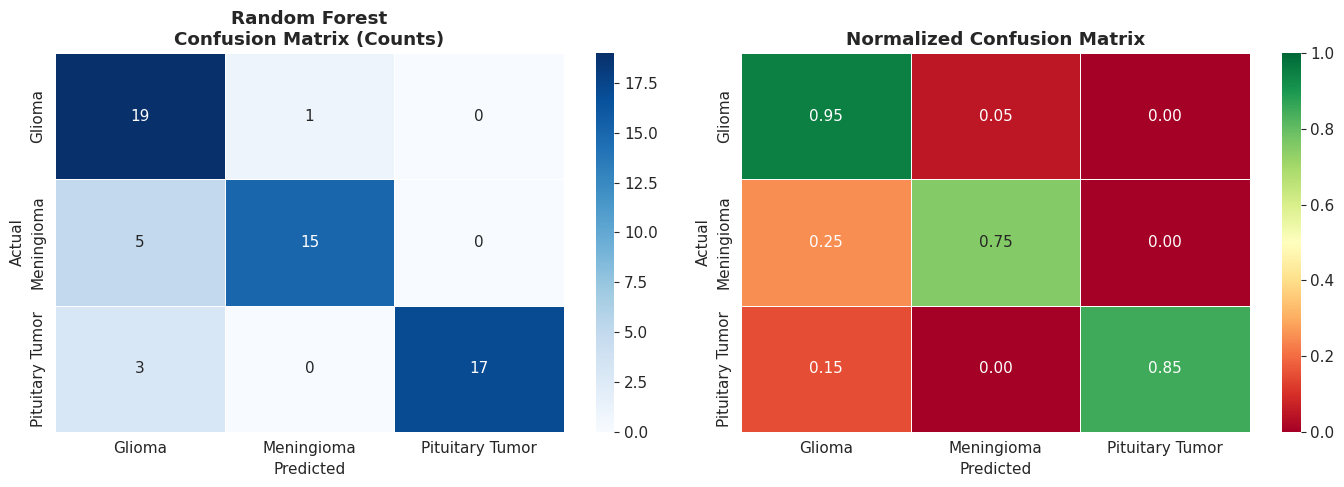

✓ Saved: data/outputs/ae_confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test, best_result['y_pred'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title(f'{best_name}\nConfusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Normalized Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_confusion_matrix.png")


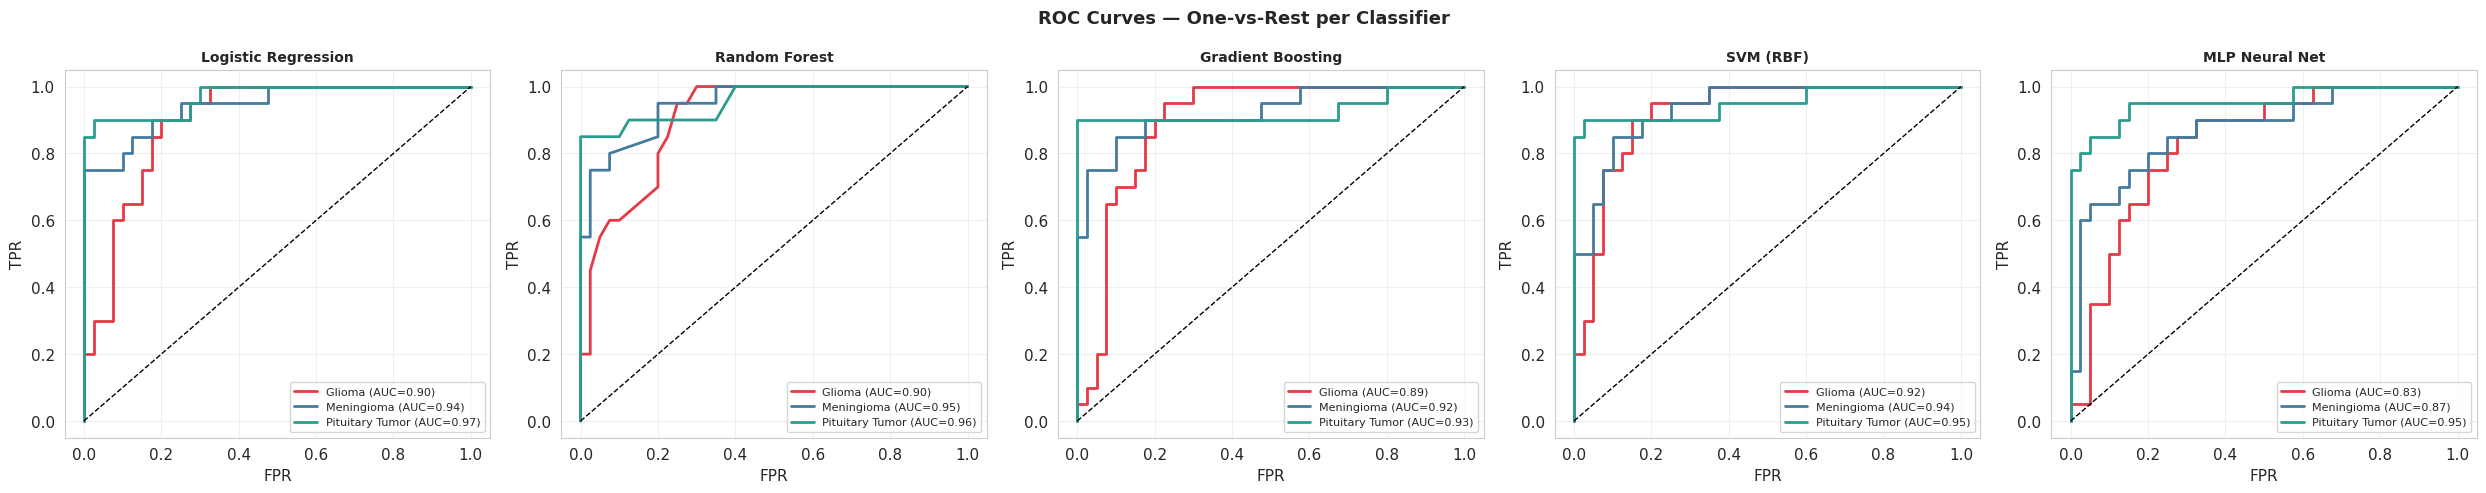

✓ Saved: data/outputs/ae_roc_curves.png


In [ ]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (name, result) in zip(axes, results.items()):
    for cls_idx, (cls_name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], result['y_prob'][:, cls_idx])
        auc_cls = roc_auc_score(y_test_bin[:, cls_idx], result['y_prob'][:, cls_idx])
        ax.plot(fpr, tpr, lw=2, color=color, label=f'{cls_name} (AUC={auc_cls:.2f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — One-vs-Rest per Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_roc_curves.png")


## 8. Feature Importance (Random Forest on Latent Dims)

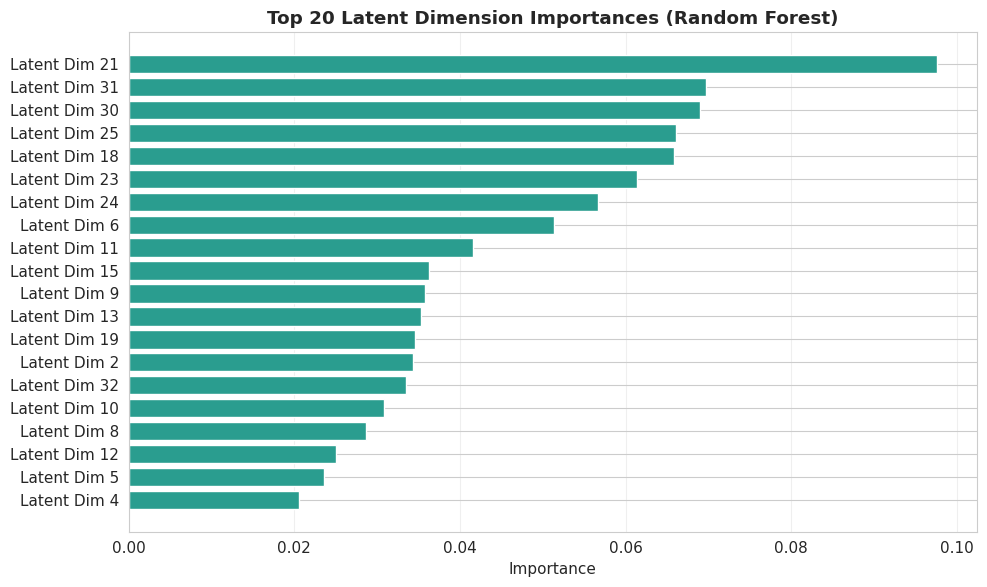

✓ Saved: data/outputs/ae_feature_importance.png


In [ ]:
if 'Random Forest' in results:
    rf = results['Random Forest']['model']
    importances = rf.feature_importances_
    top_n = 20
    top_idx = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(top_n), importances[top_idx], color='#2A9D8F', edgecolor='white', linewidth=1)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([f'Latent Dim {i+1}' for i in top_idx])
    ax.set_xlabel('Importance')
    ax.set_title('Top 20 Latent Dimension Importances (Random Forest)', fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'ae_feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {OUTPUT_DIR}/ae_feature_importance.png")


## 9. Reconstruction Error Analysis per Class

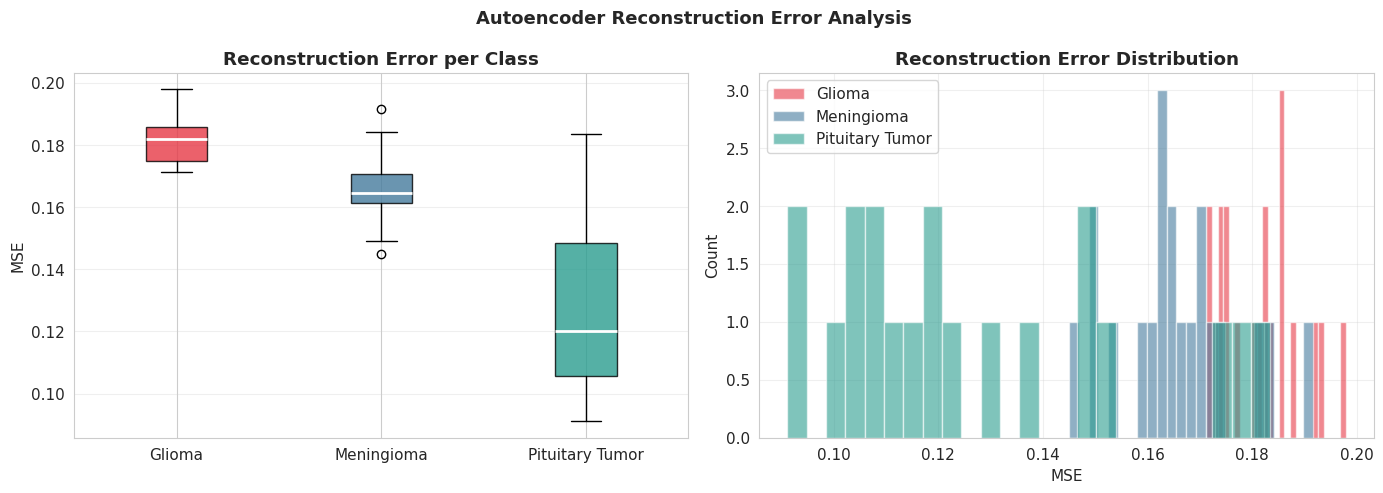

✓ Saved: data/outputs/ae_reconstruction_error.png
  Glioma                mean=0.18152  std=0.00752
  Meningioma            mean=0.16588  std=0.01130
  Pituitary Tumor       mean=0.12747  std=0.02728


In [ ]:
# Compute per-sample MSE reconstruction error on test set
recon_errors = []
for i in range(len(X_test_raw)):
    orig  = X_test_raw[i:i+1]
    recon = ae.forward(orig)
    err   = np.mean((recon - orig) ** 2)
    recon_errors.append(err)
recon_errors = np.array(recon_errors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data_by_class = [recon_errors[y_test == i] for i in range(3)]
bp = axes[0].boxplot(data_by_class, labels=CLASS_NAMES, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title('Reconstruction Error per Class', fontweight='bold')
axes[0].set_ylabel('MSE')
axes[0].grid(True, axis='y', alpha=0.3)

# Histogram overlay
for i, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    axes[1].hist(recon_errors[y_test == i], bins=25, alpha=0.6,
                  color=color, label=name, edgecolor='white')
axes[1].set_title('Reconstruction Error Distribution', fontweight='bold')
axes[1].set_xlabel('MSE')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Autoencoder Reconstruction Error Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_reconstruction_error.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/ae_reconstruction_error.png")

for i, name in enumerate(CLASS_NAMES):
    errs = recon_errors[y_test == i]
    print(f"  {name:20s}  mean={errs.mean():.5f}  std={errs.std():.5f}")


## 10. Summary

In [ ]:
print("\n" + "="*65)
print("  BRAIN TUMOR DETECTION — AUTOENCODER PIPELINE COMPLETE")
print("="*65)
print(f"\n  Dataset       : Glioma | Meningioma | Pituitary Tumor")
print(f"  Total images  : {len(X_raw)}")
print(f"  Latent dim    : {LATENT_DIM}")
print(f"  AE final loss : {ae.train_losses[-1]:.6f}")
print(f"\n  Best Classifier : {best_name}")
print(f"  Test Accuracy   : {best_result['accuracy']:.4f}")
print(f"  Test F1-Score   : {best_result['f1']:.4f}")
print(f"  Test AUC (OvR)  : {best_result['auc']:.4f}")
print(f"\n  Generated Files (in '{OUTPUT_DIR}/' folder):")
files = [
    "ae_class_distribution.png",
    "ae_sample_images.png",
    "ae_training_loss.png",
    "ae_reconstruction.png",
    "ae_latent_pca.png",
    "ae_latent_tsne.png",
    "ae_model_comparison.png",
    "ae_model_comparison.csv",
    "ae_confusion_matrix.png",
    "ae_roc_curves.png",
    "ae_feature_importance.png",
    "ae_reconstruction_error.png",
]
for i, f in enumerate(files, 1):
    print(f"    {i:2d}. {OUTPUT_DIR}/{f}")
print("\n" + "="*65)



  BRAIN TUMOR DETECTION — AUTOENCODER PIPELINE COMPLETE

  Dataset       : Glioma | Meningioma | Pituitary Tumor
  Total images  : 300
  Latent dim    : 32
  AE final loss : 0.157506

  Best Classifier : Random Forest
  Test Accuracy   : 0.8500
  Test F1-Score   : 0.8536
  Test AUC (OvR)  : 0.9356

  Generated Files (in 'data/outputs/' folder):
     1. data/outputs/ae_class_distribution.png
     2. data/outputs/ae_sample_images.png
     3. data/outputs/ae_training_loss.png
     4. data/outputs/ae_reconstruction.png
     5. data/outputs/ae_latent_pca.png
     6. data/outputs/ae_latent_tsne.png
     7. data/outputs/ae_model_comparison.png
     8. data/outputs/ae_model_comparison.csv
     9. data/outputs/ae_confusion_matrix.png
    10. data/outputs/ae_roc_curves.png
    11. data/outputs/ae_feature_importance.png
    12. data/outputs/ae_reconstruction_error.png

